# Spotify Hit Prediction — ML Pipeline
**Models:** Logistic Regression · Random Forest · XGBoost (with hyperparameter tuning)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv("spotify_top_songs_audio_features.csv")
df.head()

,id,artist_names,track_name,source,key,mode,time_signature,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,loudness,tempo,duration_ms,weeks_on_chart,streams
0,000xQL6tZNLJzIrtIgxqSl,"ZAYN, PARTYNEXTDOOR",Still Got Time (feat. PARTYNEXTDOOR),RCA Records Label,G,Major,4 beats,0.748,0.627,0.0639,0.13100,0.0,0.0852,0.524,-6.029,120.963,188491,17,107527761
1,003eoIwxETJujVWmNFMoZy,Alessia Cara,Growing Pains,Def Jam Recordings,C#/Db,Minor,4 beats,0.353,0.755,0.7330,0.08220,0.0,0.3900,0.437,-6.276,191.153,193680,2,9944865
2,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,Island Records,C#/Db,Major,4 beats,0.352,0.911,0.0747,0.00121,0.0,0.0995,0.236,-5.230,148.033,222973,125,512388123
3,00B7TZ0Xawar6NZ00JFomN,"Cardi B, Chance the Rapper",Best Life (feat. Chance The Rapper),Atlantic/KSR,A,Major,4 beats,0.620,0.625,0.5530,0.28700,0.0,0.3140,0.665,-7.438,167.911,284856,2,11985346
4,00Blm7zeNqgYLPtW6zg8cj,"Post Malone, The Weeknd",One Right Now (with The Weeknd),Republic Records,C#/Db,Major,4 beats,0.687,0.781,0.0530,0.03610,0.0,0.0755,0.688,-4.806,97.014,193507,30,301860377


In [5]:
print(f"Shape: {df.shape}")

print(f"\nColumns: {list(df.columns)}")

Shape: (6513, 19)

Columns: ['id', 'artist_names', 'track_name', 'source', 'key', 'mode', 'time_signature', 'danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'loudness', 'tempo', 'duration_ms', 'weeks_on_chart', 'streams']


## Target Engineering

In [6]:
median_weeks = df['weeks_on_chart'].median()
df['hit'] = (df['weeks_on_chart'] >= median_weeks).astype(int)

print(f"Median weeks on chart: {median_weeks}")
print(f"Hit distribution:\n{df['hit'].value_counts()}")

Median weeks on chart: 4.0
Hit distribution:
hit
1    3562
0    2951
Name: count, dtype: int64


## Feature Setup

In [7]:
numeric_cols = [
    "danceability", "energy", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence",
    "loudness", "tempo", "duration_ms"
]

categorical_cols = ["key", "mode", "time_signature"]

X = df[numeric_cols + categorical_cols]
y = df['hit']

print(f"Features: {X.shape[1]} | Samples: {X.shape[0]}")

Features: 13 | Samples: 6513


## Train/Test Split & Preprocessor

In [8]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11, stratify=y
)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 5210 | Test size: 1303


## Model 1: Logistic Regression

In [9]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"]
}

gs_lr = GridSearchCV(
    lr_pipeline, lr_param_grid,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)

gs_lr.fit(X_train, y_train)
print("Best LR Params:", gs_lr.best_params_)
print(f"Best CV Accuracy: {gs_lr.best_score_:.4f}")

Best LR Params: {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best CV Accuracy: 0.5860


## Model 2: Random Forest

In [10]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=11))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

gs_rf = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)

gs_rf.fit(X_train, y_train)
print("Best RF Params:", gs_rf.best_params_)
print(f"Best CV Accuracy: {gs_rf.best_score_:.4f}")

Best RF Params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV Accuracy: 0.6152


## Model 3: XGBoost with Hyperparameter Tuning

Using `RandomizedSearchCV` instead of `GridSearchCV` — the XGBoost param space is large (n_estimators × max_depth × learning_rate × subsample × colsample = 54+ combos), so random search finds good params ~10x faster with comparable results.

In [ ]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    ))
])

xgb_param_dist = {
    'classifier__n_estimators':    [100, 200, 300, 500],
    'classifier__max_depth':       [3, 4, 5, 6],
    'classifier__learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample':       [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree':[0.7, 0.8, 0.9, 1.0],
    'classifier__min_child_weight':[1, 3, 5],
    'classifier__gamma':           [0, 0.1, 0.2]
}

gs_xgb = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_dist,
    n_iter=30,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

gs_xgb.fit(X_train, y_train)
print("\nBest XGBoost Params:", gs_xgb.best_params_)
print(f"Best CV Accuracy: {gs_xgb.best_score_:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGBoost Params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 3, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0.2, 'classifier__colsample_bytree': 0.9}
Best CV Accuracy: 0.6088


## Accuracy Comparison

In [12]:
lr_train_acc  = accuracy_score(y_train, gs_lr.predict(X_train))
rf_train_acc  = accuracy_score(y_train, gs_rf.predict(X_train))
xgb_train_acc = accuracy_score(y_train, gs_xgb.predict(X_train))

lr_test_acc  = accuracy_score(y_test, gs_lr.predict(X_test))
rf_test_acc  = accuracy_score(y_test, gs_rf.predict(X_test))
xgb_test_acc = accuracy_score(y_test, gs_xgb.predict(X_test))

print(f"{'Model':<22} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 44)
print(f"{'Logistic Regression':<22} {lr_train_acc:>10.4f} {lr_test_acc:>10.4f}")
print(f"{'Random Forest':<22} {rf_train_acc:>10.4f} {rf_test_acc:>10.4f}")
print(f"{'XGBoost':<22} {xgb_train_acc:>10.4f} {xgb_test_acc:>10.4f}")


Model                   Train Acc   Test Acc
--------------------------------------------
Logistic Regression        0.5910     0.5549
Random Forest              0.8390     0.5948
XGBoost                    0.7175     0.5833


## Accuracy Plot

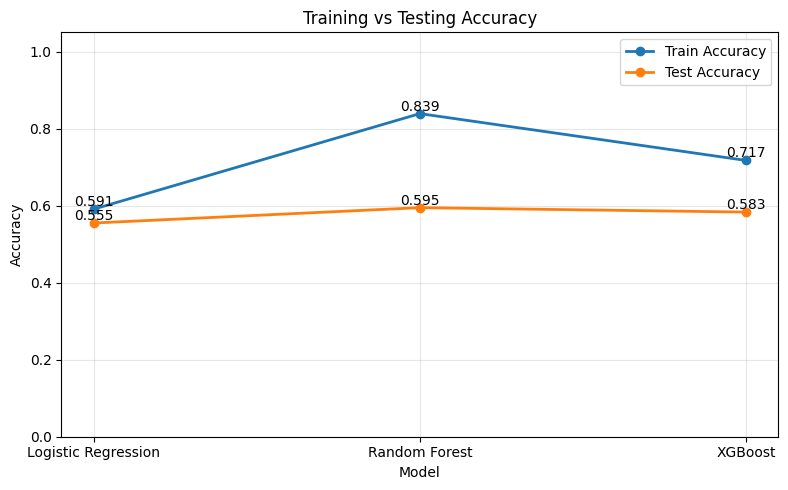

In [13]:
import matplotlib.pyplot as plt

model_names = ["Logistic Regression", "Random Forest", "XGBoost"]
train_accs = [lr_train_acc, rf_train_acc, xgb_train_acc]
test_accs = [lr_test_acc, rf_test_acc, xgb_test_acc]

plt.figure(figsize=(8, 5))

plt.plot(model_names, train_accs, marker='o', linewidth=2, label='Train Accuracy')
plt.plot(model_names, test_accs, marker='o', linewidth=2, label='Test Accuracy')

plt.title('Training vs Testing Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()

for i, acc in enumerate(train_accs):
    plt.text(i, acc, f'{acc:.3f}', ha='center', va='bottom')

for i, acc in enumerate(test_accs):
    plt.text(i, acc, f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Classification Reports

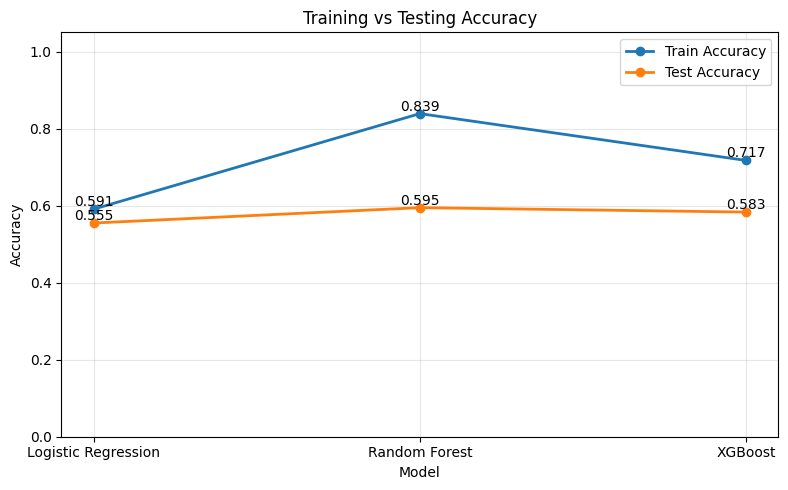

In [14]:
import matplotlib.pyplot as plt

model_names = ["Logistic Regression", "Random Forest", "XGBoost"]
train_accs = [lr_train_acc, rf_train_acc, xgb_train_acc]
test_accs = [lr_test_acc, rf_test_acc, xgb_test_acc]

plt.figure(figsize=(8, 5))

plt.plot(model_names, train_accs, marker='o', linewidth=2, label='Train Accuracy')
plt.plot(model_names, test_accs, marker='o', linewidth=2, label='Test Accuracy')

plt.title('Training vs Testing Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()

for i, acc in enumerate(train_accs):
    plt.text(i, acc, f'{acc:.3f}', ha='center', va='bottom')

for i, acc in enumerate(test_accs):
    plt.text(i, acc, f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [15]:
for name, model in [("Logistic Regression", gs_lr), ("Random Forest", gs_rf), ("XGBoost", gs_xgb)]:
    print(f"\n{'='*50}")
    print(f" {name}")
    print('='*50)
    print(classification_report(y_test, model.predict(X_test), target_names=['Not Hit', 'Hit']))


 Logistic Regression
              precision    recall  f1-score   support

     Not Hit       0.51      0.34      0.41       590
         Hit       0.57      0.73      0.64       713

    accuracy                           0.55      1303
   macro avg       0.54      0.54      0.53      1303
weighted avg       0.55      0.55      0.54      1303


 Random Forest
              precision    recall  f1-score   support

     Not Hit       0.57      0.42      0.49       590
         Hit       0.61      0.74      0.67       713

    accuracy                           0.59      1303
   macro avg       0.59      0.58      0.58      1303
weighted avg       0.59      0.59      0.58      1303


 XGBoost
              precision    recall  f1-score   support

     Not Hit       0.55      0.41      0.47       590
         Hit       0.60      0.73      0.66       713

    accuracy                           0.58      1303
   macro avg       0.58      0.57      0.56      1303
weighted avg       0.58   

## Save Best Model

FIX: Saves the **best overall model** (whichever has highest test accuracy) instead of always saving RF.

In [19]:
import pickle

results = {
    'Logistic Regression': (gs_lr, lr_test_acc),
    'Random Forest':       (gs_rf, rf_test_acc),
    'XGBoost':             (gs_xgb, xgb_test_acc)
}

best_name, (best_estimator, best_acc) = max(results.items(), key=lambda x: x[1][1])

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_estimator.best_estimator_, f)

print(f"Best model: {best_name} (Test Accuracy: {best_acc:.4f})")
print("Saved to best_model.pkl")


Best model: Random Forest (Test Accuracy: 0.5948)
Saved to best_model.pkl
